In [28]:
import matplotlib.pyplot as plt
import numpy as np

In [29]:
# cols [list_size,threads,err,time,qsort_time]
data = open('out.txt','r')
D = []
for line in data:
    L = line.split(',')[:3]
    L[0] = float(L[0].split(' ')[-1])
    L[1] = float(L[1].split(' ')[-1])
    L[2] = float(L[2].split(' ')[-2])
    D.append(L)
labels = ['Matrix Size','Leaf Matrix Size','Strassen\'s (s)']
print(labels)
for i in D:
    print(i)
D = np.array(D)
# print(D)

['Matrix Size', 'Leaf Matrix Size', "Strassen's (s)"]
[1024.0, 4.0, 4.4592]
[1024.0, 4.0, 6.3869]
[1024.0, 8.0, 1.6034]
[1024.0, 8.0, 4.5077]
[1024.0, 16.0, 1.2469]
[1024.0, 16.0, 3.2634]
[1024.0, 32.0, 0.804]
[1024.0, 32.0, 4.8699]
[1024.0, 64.0, 0.6581]
[1024.0, 64.0, 4.4034]
[1024.0, 128.0, 1.3075]
[1024.0, 128.0, 4.2437]
[2048.0, 8.0, 7.9707]
[2048.0, 8.0, 7.9853]
[2048.0, 16.0, 4.1977]
[2048.0, 16.0, 6.4165]
[2048.0, 32.0, 4.3541]
[2048.0, 32.0, 6.6424]
[2048.0, 64.0, 5.1936]
[2048.0, 64.0, 6.7025]
[2048.0, 128.0, 6.1064]
[2048.0, 128.0, 6.7886]
[2048.0, 256.0, 7.234]
[2048.0, 256.0, 6.616]
[4096.0, 16.0, 28.9249]
[4096.0, 16.0, 19.3527]
[4096.0, 32.0, 26.9067]
[4096.0, 32.0, 18.1137]
[4096.0, 64.0, 31.1041]
[4096.0, 64.0, 21.9211]
[4096.0, 128.0, 37.1456]
[4096.0, 128.0, 22.9381]
[4096.0, 256.0, 43.272]
[4096.0, 256.0, 23.4618]
[4096.0, 512.0, 132.8941]
[4096.0, 512.0, 28.5286]
[8192.0, 32.0, 183.631]
[8192.0, 32.0, 45.9481]
[8192.0, 64.0, 215.0101]
[8192.0, 64.0, 51.14]
[8192.0,

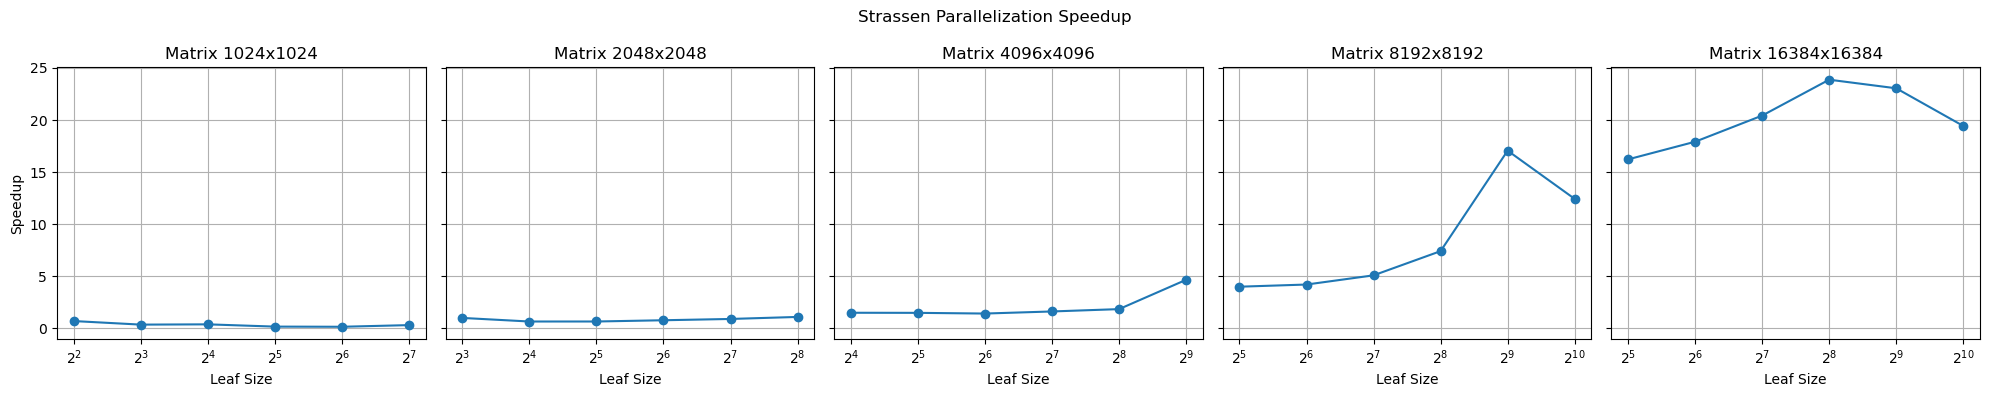

In [30]:
O = {} # MatSize:  LeafSize: Speedup
for i in range(0,len(D),2):
    if D[i][0] not in O:
        O[D[i][0]] = {}
    O[D[i][0]][D[i][1]] = D[i][2]/D[i+1][2]
mat_sizes = list(O.keys())
n = len(mat_sizes)
fig, axes = plt.subplots(1,len(O), figsize=(4*n, 4), sharey=True)
for ax, mat_size in zip(axes, mat_sizes):
    leaf_sizes = list(O[mat_size].keys())
    speedups = list(O[mat_size].values())
    
    ax.plot(leaf_sizes, speedups, marker='o')
    ax.set_title(f'Matrix {int(mat_size)}x{int(mat_size)}')
    ax.set_xlabel('Leaf Size')
    ax.set_xscale('log', base=2)   # leaf sizes are powers of 2
    ax.grid(True)

axes[0].set_ylabel('Speedup')
fig.suptitle('Strassen Parallelization Speedup')
plt.tight_layout()
plt.savefig('speedup.png', dpi=150)
plt.show()

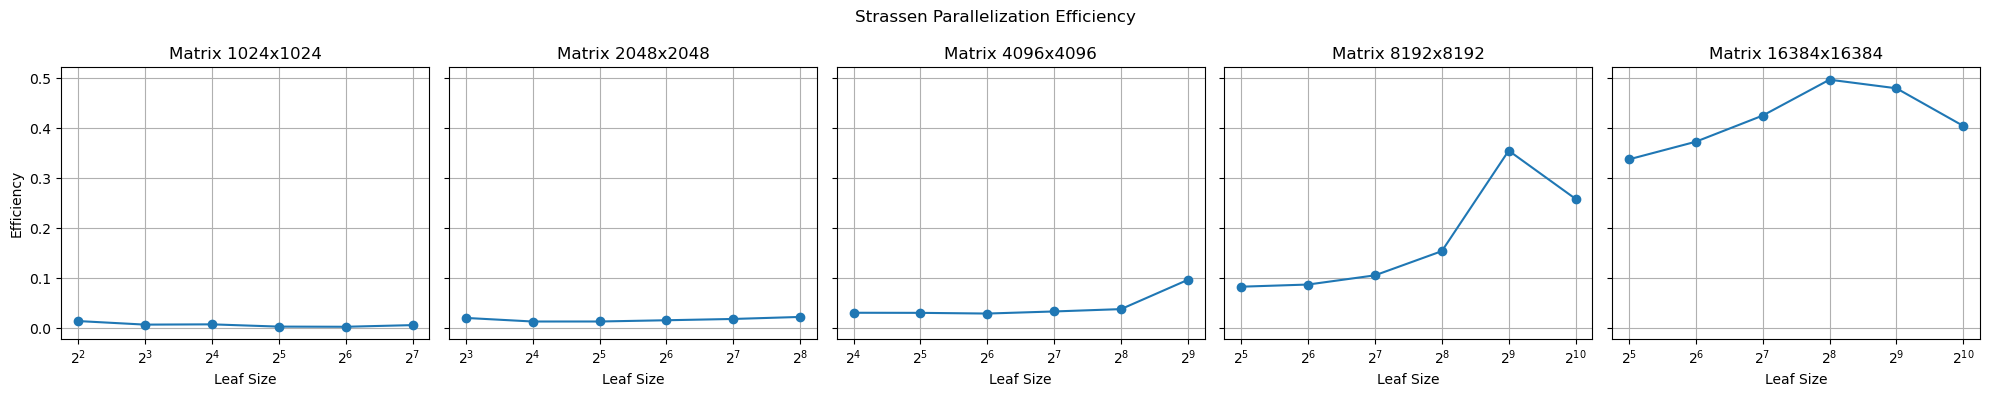

1024
	4: 0.6981790853152547
	8: 0.35570246467156197
	16: 0.3820861678004535
	32: 0.16509579252140702
	64: 0.14945269564427488
	128: 0.3081037773640927
2048
	8: 0.9981716403892152
	16: 0.6542040052988389
	32: 0.6555010237263639
	64: 0.7748750466243939
	128: 0.8995079987037091
	256: 1.093409915356711
4096
	16: 1.4946183219912468
	32: 1.485433677271899
	64: 1.418911459735141
	128: 1.6193843430798542
	256: 1.8443597677927523
	512: 4.658276256107906
8192
	32: 3.9964873411523003
	64: 4.204342980054752
	128: 5.08770486440836
	256: 7.41132548788136
	512: 17.058034217288643
	1024: 12.428677615701583
16384
	32: 16.221614486770786
	64: 17.915101192086937
	128: 20.424180591387632
	256: 23.87212137109091
	512: 23.046209973802142
	1024: 19.43191482223189


In [31]:
fig, axes = plt.subplots(1,len(O), figsize=(4*n, 4), sharey=True)
for ax, mat_size in zip(axes, mat_sizes):
    leaf_sizes = list(O[mat_size].keys())
    efficiency = [s/48 for s in O[mat_size].values()]
    
    ax.plot(leaf_sizes, efficiency, marker='o')
    ax.set_title(f'Matrix {int(mat_size)}x{int(mat_size)}')
    ax.set_xlabel('Leaf Size')
    ax.set_xscale('log', base=2)   # leaf sizes are powers of 2
    ax.grid(True)

axes[0].set_ylabel('Efficiency')
fig.suptitle('Strassen Parallelization Efficiency')
plt.tight_layout()
plt.savefig('efficiency.png', dpi=150)
plt.show()
for i in O.keys():
    print(int(i))
    for j in O[i].keys():
        print(f'\t{int(j)}: {O[i][j]}')

icpx -qopenmp -o strass.exe strassen7.cpp
./strass.exe <k> <q>
We start seeing benefit to multi-processing the data as the size input for the matrix grows. When the matrix is 2^13x2^13, parallelized multi-processing starts actually being a speedup, and increasing the leaf size increases the speedup as well. This is likely due to less recursion steps and more opportunity for the processors to process larger matrices, and we see a sweet spot where this benefit begins to drop-off. Since E=S/p using p=48 processors, our efficiency graphs mirror speedup. We see as the matrix size increases that so does efficiency